In [ ]:
# RUN THIS COMMAND ONLY IF YOU USE GOOGLE COLAB.
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# RUN THIS COMMAND ONLY IF YOU USE GOOGLE COLAB.
%cd drive/MyDrive/TechLabs/02_Data\ Manipulation/Part\ B\ -\ Numpy

In [2]:
# ALWAYS IMPORT NUMPY FIRST.
import numpy as np
# LIBRARIES NEEDED FOR THE EXAMPLE.
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()

# Chapter 9 - A Boolean Mask on NumPy Arrays
### Hey Techie,   
Welcome to the final notebook of this Numpy tutorial series. We encourage you to take this notebook as a template to code along the instruction video, which you may find at: https://youtu.be/LL7dnUymOvo. Today's video explains how to use boolean masks in Numpy arrays. In the end, please try to solve the presented tasks. In case you are interested, you find a complete walk through the tasks at: https://youtu.be/e6C1Z-o1fyQ. 

#### Have fun! :-)   
*Video length in total*: 28 minutes   
*Self-study time*: 28 minutes   
*Total*: **56 minutes**   
#### Credits
Complete Python Numpy Tutorial for Beginners, Nate at StrataScratch, https://www.youtube.com/channel/UCW8Ews7tdKKkBT6GdtQaXvQ.
<hr style="border:2px solid gray"> </hr>   

# Comparisons, Masks, and Boolean Logic

This section covers the use of Boolean masks to examine and manipulate values within NumPy arrays.
Masking comes up when you want to extract, modify, count, or otherwise manipulate values in an array based on some criterion: for example, you might wish to count all values greater than a certain value, or perhaps remove all outliers that are above some threshold.
In NumPy, Boolean masking is often the most efficient way to accomplish these types of tasks.

## Example: Counting Rainy Days

Imagine you have a series of data that represents the amount of precipitation each day for a year in a given city.
For example, here we'll load the daily rainfall statistics for the city of Seattle in 2014 using pandas.

### Import data from the Strata Scratch platform

In [3]:
rainfall = pd.read_csv('data/seattle_2014.csv')
rainfall.head()

,station,station_name,date,prcp,snwd,snow,tmax,tmin,awnd,wdf2,wdf5,wsf2,wsf5,wt01,wt05,wt02,wt03
0,GHCND:USW00024233,SEATTLE TACOMA INTERNATIONAL AIRPORT WA US,20140101,0,0,0,72,33,12,340,310,36,40,-9999,-9999,-9999,-9999
1,GHCND:USW00024233,SEATTLE TACOMA INTERNATIONAL AIRPORT WA US,20140102,41,0,0,106,61,32,190,200,94,116,-9999,-9999,-9999,-9999
2,GHCND:USW00024233,SEATTLE TACOMA INTERNATIONAL AIRPORT WA US,20140103,15,0,0,89,28,26,30,50,63,72,1,-9999,-9999,-9999
3,GHCND:USW00024233,SEATTLE TACOMA INTERNATIONAL AIRPORT WA US,20140104,0,0,0,78,6,27,40,40,45,58,1,-9999,-9999,-9999
4,GHCND:USW00024233,SEATTLE TACOMA INTERNATIONAL AIRPORT WA US,20140105,0,0,0,83,-5,37,10,10,67,76,-9999,-9999,-9999,-9999


In [4]:
inches = rainfall['prcp'] / 254.0  # 1/10mm -> inches
inches.shape

(365,)

The array contains 365 values, giving daily rainfall in inches from January 1 to December 31, 2014.

As a first quick visualization, let's look at the histogram of rainy days, which was generated using Matplotlib.

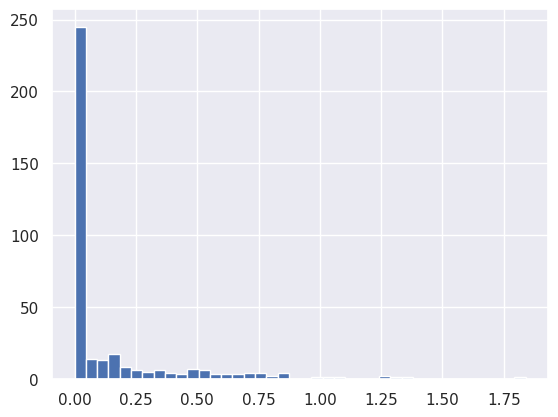

In [5]:
plt.hist(inches, 40);

This histogram gives us a general idea of what the data looks like: despite its reputation, the vast majority of days in Seattle saw near zero measured rainfall in 2014.
But this doesn't do a good job of conveying some information we'd like to see: for example, how many rainy days were there in the year? What is the average precipitation on those rainy days? How many days were there with more than half an inch of rain?

## Comparison Operators as ufuncs

We introduced ufuncs, and focused in particular on arithmetic operators. We saw that using ``+``, ``-``, ``*``, ``/``, and others on arrays leads to element-wise operations.
NumPy also implements comparison operators such as ``<`` (less than) and ``>`` (greater than) as element-wise ufuncs.
The result of these comparison operators is always an array with a Boolean data type.
All six of the standard comparison operations are available:

In [6]:
x = np.array([1, 2, 3, 4, 5])
print(x)

[1 2 3 4 5]


In [7]:
x < 3  # less than

array([ True,  True, False, False, False])

In [8]:
x > 3  # greater than

array([False, False, False,  True,  True])

In [9]:
x <= 3  # less than or equal

array([ True,  True,  True, False, False])

In [10]:
x >= 3  # greater than or equal

array([False, False,  True,  True,  True])

In [11]:
x != 3  # not equal

array([ True,  True, False,  True,  True])

In [12]:
x == 3  # equal

array([False, False,  True, False, False])

It is also possible to do an element-wise comparison of two arrays, and to include compound expressions:

In [13]:
(2 * x) == (x ** 2)

array([False,  True, False, False, False])

As in the case of arithmetic operators, the comparison operators are implemented as ufuncs in NumPy; for example, when you write ``x < 3``, internally NumPy uses ``np.less(x, 3)``.
    A summary of the comparison operators and their equivalent ufunc is shown here:

| Operator	    | Equivalent ufunc    || Operator	   | Equivalent ufunc    |
|---------------|---------------------||---------------|---------------------|
|``==``         |``np.equal``         ||``!=``         |``np.not_equal``     |
|``<``          |``np.less``          ||``<=``         |``np.less_equal``    |
|``>``          |``np.greater``       ||``>=``         |``np.greater_equal`` |

Just as in the case of arithmetic ufuncs, these will work on arrays of any size and shape.
Here is a two-dimensional example:

In [18]:
rng = np.random.RandomState(0)
x = rng.randint(10, size=(3, 4))
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [19]:
x < 6

array([[ True,  True,  True,  True],
       [False, False,  True,  True],
       [ True,  True, False, False]])

In each case, the result is a Boolean array, and NumPy provides a number of straightforward patterns for working with these Boolean results.

## Boolean Arrays as Masks

In the preceding section we looked at aggregates computed directly on Boolean arrays.
A more powerful pattern is to use Boolean arrays as masks, to select particular subsets of the data themselves.
Returning to our ``x`` array from before, suppose we want an array of all values in the array that are less than, say, 5:

In [20]:
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

We can obtain a Boolean array for this condition easily, as we've already seen:

In [21]:
x < 5

array([[False,  True,  True,  True],
       [False, False,  True, False],
       [ True,  True, False, False]])

Now to *select* these values from the array, we can simply index on this Boolean array; this is known as a *masking* operation:

In [22]:
x[x < 5]

array([0, 3, 3, 3, 2, 4])

What is returned is a one-dimensional array filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is ``True``.

We are then free to operate on these values as we wish.
For example, we can compute some relevant statistics on our Seattle rain data:

In [23]:
# construct a mask of all rainy days
rainy = (inches > 0)

# construct a mask of all summer days (June 21st is the 172nd day)
days = np.arange(365)
summer = (days > 172) & (days < 262)

print("Median precip on rainy days in 2014 (inches):   ",
      np.median(inches[rainy]))
print("Median precip on summer days in 2014 (inches):  ",
      np.median(inches[summer]))
print("Maximum precip on summer days in 2014 (inches): ",
      np.max(inches[summer]))
print("Median precip on non-summer rainy days (inches):",
      np.median(inches[rainy & ~summer]))

Median precip on rainy days in 2014 (inches):    0.19488188976377951
Median precip on summer days in 2014 (inches):   0.0
Maximum precip on summer days in 2014 (inches):  0.8503937007874016
Median precip on non-summer rainy days (inches): 0.20078740157480315


By combining Boolean operations, masking operations, and aggregates, we can very quickly answer these sorts of questions for our dataset.

<hr style="border:2px solid gray"> </hr>   

## Practice Tasks
#### 1. Create a boolean mask of x for values less than or equal to 2.

In [26]:
x = np.arange(-3, 5)
# START YOUR CODE HERE.
print(x)
print(x<=2)
print(np.less_equal(x,2))

[-3 -2 -1  0  1  2  3  4]
[ True  True  True  True  True  True False False]
[ True  True  True  True  True  True False False]


<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x <= 2</code><br />
</p>
</details>

#### 2. Create a boolean mask of x for values equal to -1.

In [27]:
# START YOUR CODE HERE.
print(x == -1)
print(np.equal(x,-1))

[False False  True False False False False False]
[False False  True False False False False False]


<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x == -1</code><br />
</p>
</details>

#### 3. Create a boolean mask of x for all positive values.

In [28]:
# START YOUR CODE HERE.
print(x>0)
print(np.greater(x,0))

[False False False False  True  True  True  True]
[False False False False  True  True  True  True]


<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x > 0</code><br />
</p>
</details>

#### 4. Create a boolean mask of x for all even values. (Hint:  Modulo)

In [31]:
# START YOUR CODE HERE.
print(x % 2 == 0)
print(np.equal(np.mod(x,2),0))

[False  True False  True False  True False  True]
[False  True False  True False  True False  True]


<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x%2 == 0</code><br />
</p>
</details>

#### 5. Create a boolean mask 'greater' of x for values greater than 4. Create an array of x for values greater than four using a masking operation.

In [35]:
np.random.seed(1)  # seed for reproducibility
x = np.random.randint(10, size=(3, 4))
# START YOUR CODE HERE.
print(x)
print(x>4)
print(np.greater(x,4))

[[5 8 9 5]
 [0 0 1 7]
 [6 9 2 4]]
[[ True  True  True  True]
 [False False False  True]
 [ True  True False False]]
[[ True  True  True  True]
 [False False False  True]
 [ True  True False False]]


<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x[x > 4]</code><br />
</p>
</details>

#### 6. Create a boolean mask 'odd' of x for all odd values. Create an array of x for those odd values using a masking operation.

In [ ]:
# START YOUR CODE HERE.
mask = (x % 2 == 0)
x[mask]

array([8, 0, 0, 6, 2, 4])

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x[x%2!=0]</code><br />
</p>
</details>

#### 7. Create an array of x containing all values that are greater than 4 and are not odd using boolean operators and a masking operation.

In [40]:
# START YOUR CODE HERE.
print(x[(x > 4) & (~mask)])
x[(x > 4) & (x%2 != 0)]

[5 9 5 7 9]


array([5, 9, 5, 7, 9])

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Solution (click to expand)</b></font>
</summary>
<p>
    <code>x[(x > 4) & (x%2 != 0)]</code><br />
</p>
</details>